<a href="https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/https%2Fgithub.com%2Faminsiddik2810%2Fdata-science-2026.git/Pertemuan6_AminSiddikRangkuti_220401010124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('titanic')

cols = ['pclass','sex','age','sibsp','parch','fare','embarked','survived']
df = df[cols].copy()

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (891, 8)


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64


In [4]:
print("Tipe Data:")
print(df.info())

Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   sex       891 non-null    object 
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   embarked  889 non-null    object 
 7   survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None


In [5]:
print("Distribusi Target:")
print(df['survived'].value_counts(normalize=True).round(3))

Distribusi Target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


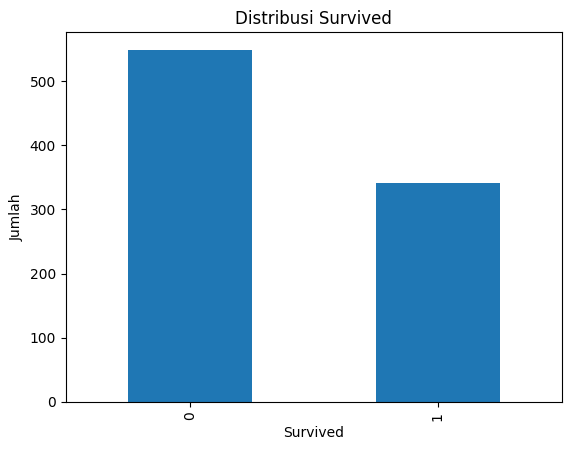

In [6]:
df['survived'].value_counts().plot(kind='bar')

plt.title("Distribusi Survived")
plt.xlabel("Survived")
plt.ylabel("Jumlah")
plt.show()

In [7]:
df['age'] = df['age'].fillna(
    df['age'].median()
)

print("Missing Age:")
print(df['age'].isnull().sum())

Missing Age:
0


In [8]:
df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

print("Missing Embarked:")
print(df['embarked'].isnull().sum())

Missing Embarked:
0


In [9]:
print("Total Missing Setelah Cleaning:")
print(df.isnull().sum())

Total Missing Setelah Cleaning:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [10]:
df = pd.get_dummies(
    df,
    columns=['sex','embarked'],
    drop_first=True,
    dtype=int
)

print(df.columns)

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male',
       'embarked_Q', 'embarked_S'],
      dtype='object')


In [11]:
df.head()

,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


In [12]:
X = df.drop(
    'survived',
    axis=1
)

y = df['survived']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (712, 8)
Test: (179, 8)


In [15]:
print(
    y_train.value_counts(
        normalize=True
    ).round(3)
)

survived
0    0.617
1    0.383
Name: proportion, dtype: float64


In [16]:
print(
    y_test.value_counts(
        normalize=True
    ).round(3)
)

survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
num_cols = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

In [19]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

In [20]:
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [21]:
print("Mean:")
print(scaler.mean_)

print()

print("Std:")
print(scaler.scale_)

Mean:
[ 2.30898876 29.45985955  0.49297753  0.39044944 31.81982626]

Std:
[ 0.83297766 13.02541729  1.05997462  0.83754512 48.02534305]


In [22]:
X_train.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
692,0.829568,-0.112078,-0.465084,-0.466183,0.513812,1,0,1
481,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,1,0,1
527,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,1,0,1
855,0.829568,-0.879807,-0.465084,0.727782,-0.467874,0,0,1
801,-0.370945,0.118241,0.478335,0.727782,-0.115977,0,0,1


In [23]:
print("X_train:",X_train.shape)
print("y_train:",y_train.shape)

print()

print("X_test:",X_test.shape)
print("y_test:",y_test.shape)

print("\nData siap digunakan")

X_train: (712, 8)
y_train: (712,)

X_test: (179, 8)
y_test: (179,)

Data siap digunakan


In [24]:
X_train.to_csv(
    "titanic_train_clean.csv",
    index=False
)

X_test.to_csv(
    "titanic_test_clean.csv",
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan
